# CardioIA — Fase 3 — Ir Além 2
## IA em Séries Temporais de Sinais Vitais
### Comparação: Regressão Logística vs Rede Neuromórfica FitzHugh–Nagumo

---

**Curso:** Inteligência Artificial — FIAP
**Fase:** 3 — Ir Além 2
**Tema:** Aplicação de IA em séries temporais de saúde (batimentos cardíacos)

### Objetivo

Aplicar duas abordagens de Inteligência Artificial sobre o mesmo problema —
classificação binária de batimentos cardíacos em **Normal** vs **Anormal** —
e compará-las criticamente em termos de desempenho, interpretabilidade e
custo computacional:

1. **Regressão Logística** — modelo estatístico clássico, linear, sem noção
   temporal (trata os 140 pontos como features independentes).
2. **Rede Neuromórfica FitzHugh–Nagumo (FHN)** — modelo bio-inspirado de
   neurônio com dinâmica não-linear, simulado com **Brian2**. O sinal ECG
   é injetado timestep a timestep e o padrão de disparos (spikes) é usado
   como representação para um classificador linear simples no topo.

### Por que essa comparação?

A Regressão Logística e o FHN representam **duas filosofias diferentes** de
processar séries temporais:

| Aspecto | Regressão Logística | FHN |
|--------|---------------------|-----|
| Origem | Estatística (1940s) | Biofísica (FitzHugh 1961 — modela potenciais de ação cardíacos/neuronais) |
| Vê o tempo? | Não — pontos avulsos | Sim — integra a dinâmica |
| Aprendizado | Gradiente sobre pesos | Parâmetros biofísicos fixos; classificador simples sobre as features de spike |
| Interpretabilidade | Pesos por timestep | Padrão de disparo bio-plausível |

### Estrutura do notebook

1. Imports e configuração
2. Carregamento do dataset ECG5000 (UCR Archive / PhysioNet BIDMC)
3. Análise exploratória (EDA)
4. Pré-processamento e binarização
5. Modelo 1 — Regressão Logística
6. Modelo 2 — Rede Neuromórfica FHN com Brian2
7. Comparação crítica
8. Conclusão e referências


## 1. Sobre o Dataset — ECG5000

**Origem:** BIDMC Congestive Heart Failure Database (PhysioNet) →
extraído por Eamonn Keogh (UC Riverside, 2015) → publicado no
**UCR Time Series Classification Archive**.

| Característica | Valor |
|----------------|-------|
| Total | 5.000 batidas cardíacas |
| Split treino | 500 |
| Split teste | 4.500 |
| Comprimento | 140 pontos por batida |
| Canais | 1 (univariado) |
| Classes | 5 (vamos agrupar para binário) |
| Licença | Open Data Commons (ODC-By) — uso acadêmico livre |

Cada amostra é uma **batida cardíaca isolada**, já segmentada pelo pico R e
normalizada. Os 140 pontos representam a amplitude do ECG ao longo de
aproximadamente 1,4 segundos.

### Classes originais

| Label | Significado clínico |
|-------|---------------------|
| 1 | Normal (N) |
| 2 | R-on-T PVC — contração ventricular prematura sobre onda T |
| 3 | PVC — contração ventricular prematura |
| 4 | SP / EB — batimento supraventricular ou ectópico |
| 5 | Unclassified |

Para esta atividade vamos **agrupar em binário**: classe `1` = Normal,
classes `2-5` = Anormal. Isto é coerente com a aplicação clínica (triagem)
e simplifica a comparação entre modelos.


In [1]:
# Imports e configuração
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Reprodutibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Estilo dos gráficos
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"

# Pasta para salvar imagens (relativa ao notebook)
IMG_DIR = Path("..") / "imagens"
IMG_DIR.mkdir(exist_ok=True)

print("Setup OK")
print(f"numpy {np.__version__} | pandas {pd.__version__}")


Setup OK
numpy 1.26.4 | pandas 2.2.3


In [2]:
# Carregamento do dataset ECG5000 via aeon
from aeon.datasets import load_classification

X_train_raw, y_train_raw = load_classification("ECG5000", split="train")
X_test_raw,  y_test_raw  = load_classification("ECG5000", split="test")

# aeon devolve no formato (n_samples, n_channels, n_timesteps)
# como é univariado, vamos achatar para (n_samples, n_timesteps)
X_train_raw = X_train_raw.squeeze(axis=1)
X_test_raw  = X_test_raw.squeeze(axis=1)

# Labels vêm como strings, converter para inteiros
y_train_raw = y_train_raw.astype(int)
y_test_raw  = y_test_raw.astype(int)

print(f"X_train: {X_train_raw.shape} | y_train: {y_train_raw.shape}")
print(f"X_test : {X_test_raw.shape}  | y_test : {y_test_raw.shape}")
print(f"Labels únicos (treino): {np.unique(y_train_raw)}")
print(f"Range de amplitude: [{X_train_raw.min():.2f}, {X_train_raw.max():.2f}]")


X_train: (500, 140) | y_train: (500,)
X_test : (4500, 140)  | y_test : (4500,)
Labels únicos (treino): [1 2 3 4 5]
Range de amplitude: [-5.80, 4.06]


## 2. Análise Exploratória (EDA)

### 2.1 Distribuição das classes originais

Vamos visualizar quantas amostras temos por classe para entender o grau de
desbalanceamento. Esse é um ponto crítico — datasets médicos costumam
ter forte viés para a classe normal.


         classe  count    pct
1        Normal   2919  58.38
2    R-on-T PVC   1767  35.34
3           PVC     96   1.92
4       SP / EB    194   3.88
5  Unclassified     24   0.48


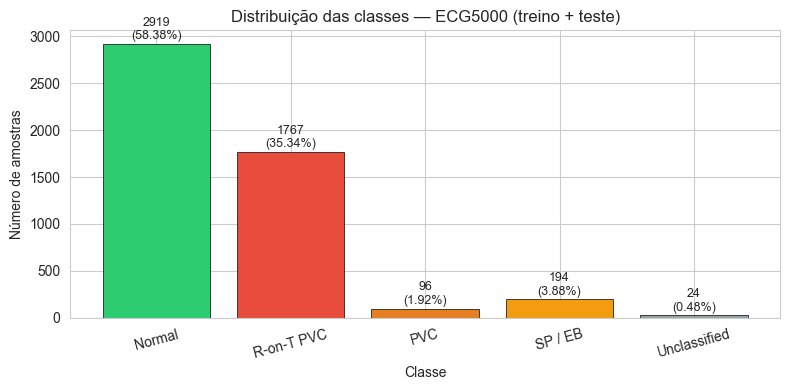

In [3]:
# Tabela de distribuição
class_names = {
    1: "Normal",
    2: "R-on-T PVC",
    3: "PVC",
    4: "SP / EB",
    5: "Unclassified",
}

# Concatena treino+teste só para EDA descritiva (NÃO usamos isso para treinar)
y_all = np.concatenate([y_train_raw, y_test_raw])

dist = (
    pd.Series(y_all)
    .value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
    .assign(
        classe=lambda d: d.index.map(class_names),
        pct=lambda d: (d["count"] / d["count"].sum() * 100).round(2),
    )
    [["classe", "count", "pct"]]
)
print(dist.to_string())

# Gráfico de barras
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#2ecc71", "#e74c3c", "#e67e22", "#f39c12", "#95a5a6"]
ax.bar(dist["classe"], dist["count"], color=colors, edgecolor="black", linewidth=0.5)
ax.set_xlabel("Classe")
ax.set_ylabel("Número de amostras")
ax.set_title("Distribuição das classes — ECG5000 (treino + teste)")
for i, v in enumerate(dist["count"]):
    ax.text(i, v + 50, f"{v}\n({dist['pct'].iloc[i]}%)", ha="center", fontsize=9)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(IMG_DIR / "01_distribuicao_classes.png")
plt.show()


### 2.2 Visualização de exemplos por classe

Plotamos alguns exemplos de cada classe para visualizar a diferença
morfológica entre os tipos de batimento. Essa é a informação que ambos
os modelos vão tentar capturar — de formas muito diferentes.


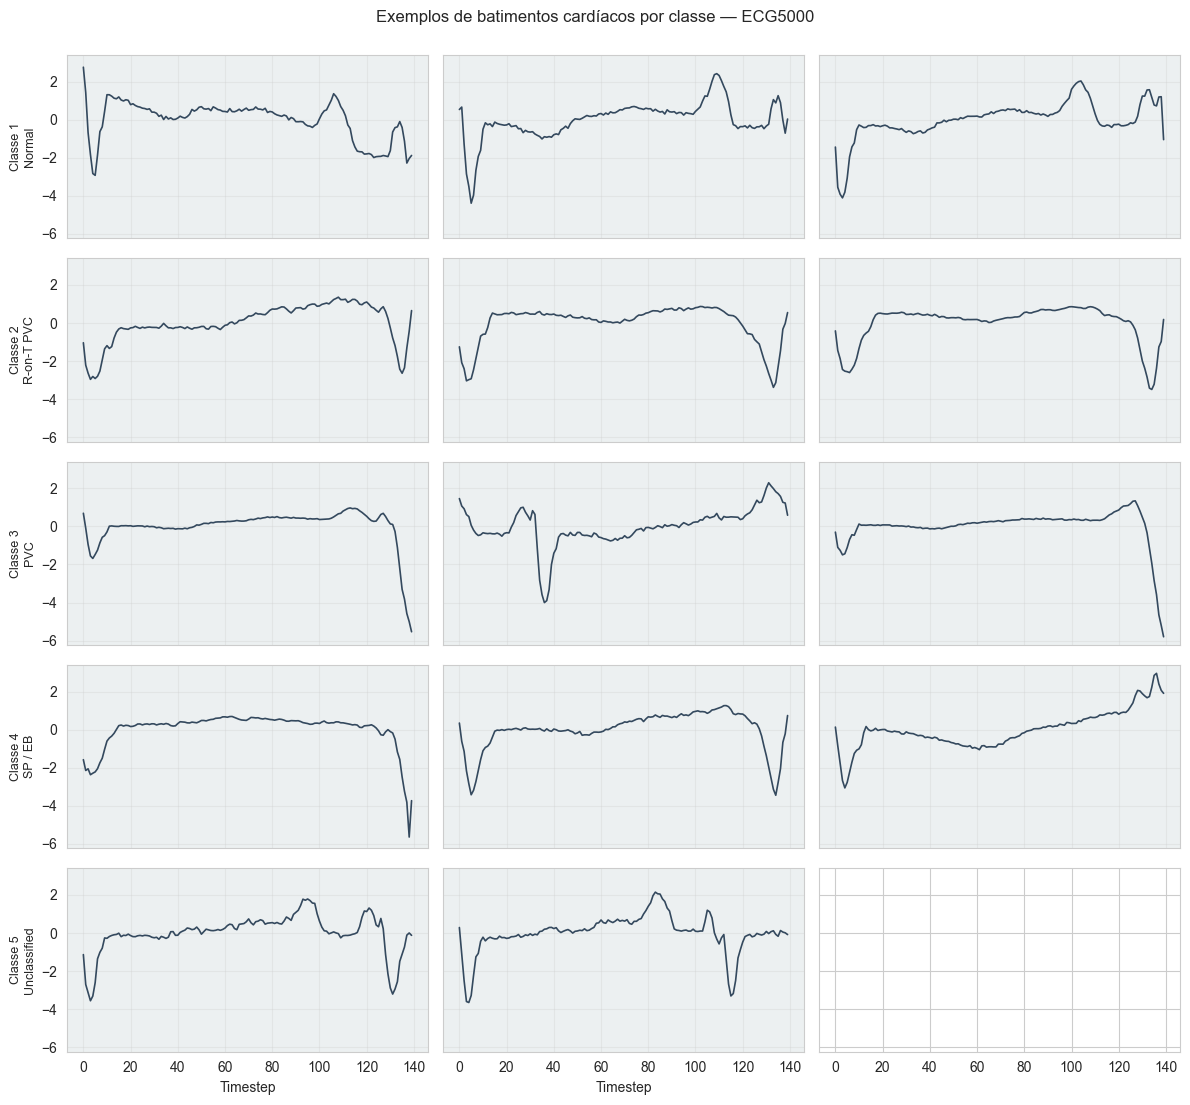

In [4]:
# Plota 3 exemplos por classe
N_EXAMPLES = 3
classes_to_plot = sorted(np.unique(y_train_raw))

fig, axes = plt.subplots(len(classes_to_plot), N_EXAMPLES,
                          figsize=(12, 2.2 * len(classes_to_plot)),
                          sharex=True, sharey=True)

rng = np.random.default_rng(RANDOM_STATE)

for row, cls in enumerate(classes_to_plot):
    idxs = np.where(y_train_raw == cls)[0]
    if len(idxs) == 0:
        idxs = np.where(y_test_raw == cls)[0]
        source = X_test_raw
    else:
        source = X_train_raw
    chosen = rng.choice(idxs, size=min(N_EXAMPLES, len(idxs)), replace=False)
    for col, i in enumerate(chosen):
        ax = axes[row, col]
        ax.plot(source[i], color="#34495e", linewidth=1.2)
        ax.set_facecolor("#ecf0f1")
        if col == 0:
            ax.set_ylabel(f"Classe {cls}\n{class_names[cls]}", fontsize=9)
        if row == len(classes_to_plot) - 1:
            ax.set_xlabel("Timestep")
        ax.grid(True, alpha=0.3)

plt.suptitle("Exemplos de batimentos cardíacos por classe — ECG5000", fontsize=12, y=1.00)
plt.tight_layout()
plt.savefig(IMG_DIR / "02_exemplos_por_classe.png")
plt.show()


## 3. Pré-processamento

Três operações antes de treinar os modelos:

1. **Binarização das classes** — agrupamos as classes 2-5 (todas anômalas) em
   uma única classe "Anormal". Isso é coerente com a aplicação de triagem
   clínica e simplifica a comparação dos modelos.
2. **Re-split estratificado** — o split original do UCR é 500 treino / 4500
   teste, o que é incomum (a maioria dos datasets usa o oposto). Como queremos
   treinar os modelos de forma justa, vamos juntar tudo e fazer um **split
   estratificado 80/20**. Mantemos a proporção das classes em ambos os
   conjuntos.
3. **Normalização (z-score por amostra)** — o dataset já vem com normalização,
   mas vamos aplicar uma normalização por amostra adicional para garantir que
   cada batida tenha média 0 e desvio 1 (importante para o FHN responder de
   forma consistente entre amostras).


In [5]:
# 3.1 Binarização: 1 -> 0 (Normal), 2-5 -> 1 (Anormal)
def to_binary(y):
    return (y != 1).astype(int)

# Junta train+test original para depois resplitar
X_all = np.concatenate([X_train_raw, X_test_raw], axis=0)
y_all_multi = np.concatenate([y_train_raw, y_test_raw], axis=0)
y_all = to_binary(y_all_multi)

bin_dist = pd.Series(y_all).value_counts().sort_index()
bin_dist.index = ["Normal (0)", "Anormal (1)"]
print("Distribuição binária:")
print(bin_dist)
print(f"\nProporção: {bin_dist[0] / bin_dist.sum() * 100:.1f}% normal / "
      f"{bin_dist[1] / bin_dist.sum() * 100:.1f}% anormal")


Distribuição binária:
Normal (0)     2919
Anormal (1)    2081
Name: count, dtype: int64

Proporção: 58.4% normal / 41.6% anormal


In [6]:
# 3.2 Re-split estratificado 80/20
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=0.20,
    stratify=y_all,
    random_state=RANDOM_STATE,
)

print(f"Treino: {X_train.shape}, classes: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Teste : {X_test.shape},  classes: {dict(zip(*np.unique(y_test, return_counts=True)))}")


Treino: (4000, 140), classes: {0: 2335, 1: 1665}
Teste : (1000, 140),  classes: {0: 584, 1: 416}


In [7]:
# 3.3 Normalização z-score por amostra
def zscore_per_sample(X, eps=1e-8):
    mu = X.mean(axis=1, keepdims=True)
    sd = X.std(axis=1, keepdims=True) + eps
    return (X - mu) / sd

X_train_norm = zscore_per_sample(X_train)
X_test_norm  = zscore_per_sample(X_test)

print(f"Treino normalizado — média global: {X_train_norm.mean():.4f}, "
      f"std global: {X_train_norm.std():.4f}")
print(f"Range por amostra: min ~ {X_train_norm.min(axis=1).mean():.2f}, "
      f"max ~ {X_train_norm.max(axis=1).mean():.2f}")


Treino normalizado — média global: -0.0000, std global: 1.0000
Range por amostra: min ~ -4.12, max ~ 1.71


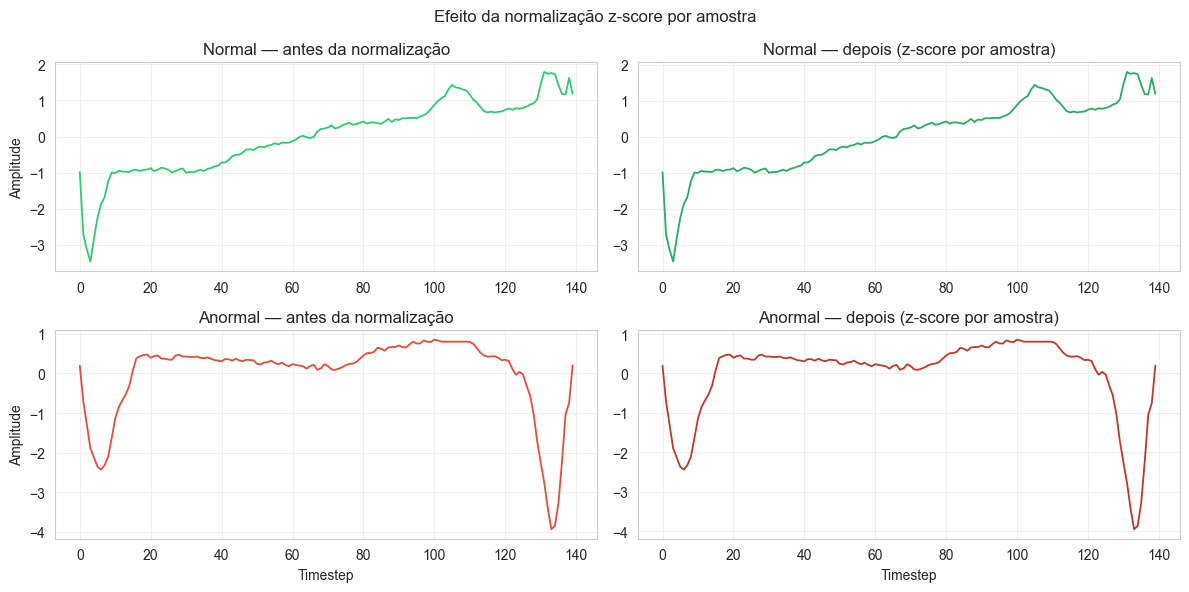

In [8]:
# 3.4 Visualização: antes vs depois da normalização
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

# Pega 1 exemplo de cada classe binária
idx_normal = np.where(y_train == 0)[0][0]
idx_anormal = np.where(y_train == 1)[0][0]

axes[0, 0].plot(X_train[idx_normal], color="#2ecc71", linewidth=1.3)
axes[0, 0].set_title("Normal — antes da normalização")
axes[0, 0].set_ylabel("Amplitude")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(X_train_norm[idx_normal], color="#27ae60", linewidth=1.3)
axes[0, 1].set_title("Normal — depois (z-score por amostra)")
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(X_train[idx_anormal], color="#e74c3c", linewidth=1.3)
axes[1, 0].set_title("Anormal — antes da normalização")
axes[1, 0].set_xlabel("Timestep")
axes[1, 0].set_ylabel("Amplitude")
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(X_train_norm[idx_anormal], color="#c0392b", linewidth=1.3)
axes[1, 1].set_title("Anormal — depois (z-score por amostra)")
axes[1, 1].set_xlabel("Timestep")
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle("Efeito da normalização z-score por amostra", fontsize=12)
plt.tight_layout()
plt.savefig(IMG_DIR / "03_normalizacao.png")
plt.show()


## 4. Modelo 1 — Regressão Logística

A Regressão Logística é o **modelo de referência** para classificação binária
em séries temporais quando tratadas como vetores de features. Cada um dos
140 timesteps vira uma feature independente e o modelo aprende um peso para
cada um.

### Características relevantes para a comparação

- **Sem noção temporal:** trata os 140 pontos como features avulsas. Se você
  embaralhasse a ordem dos pontos, o resultado seria o mesmo desde que o
  embaralhamento fosse o mesmo para treino e teste.
- **Linear:** a fronteira de decisão é um hiperplano em $\mathbb{R}^{140}$.
- **Interpretável:** os pesos têm sinal e magnitude — podemos olhar quais
  timesteps influenciam mais a decisão.
- **Rápido:** treina em milissegundos.

### Hiperparâmetros escolhidos

| Parâmetro | Valor | Justificativa |
|-----------|-------|---------------|
| `solver` | `lbfgs` | Padrão estável para problemas binários médios |
| `max_iter` | 1000 | Folga para garantir convergência |
| `C` | 1.0 | Regularização L2 padrão |
| `class_weight` | `balanced` | Precaução para o leve desbalanceamento (58/42) |


In [9]:
# 4.1 Treinamento da Regressão Logística
import time
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    C=1.0,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)

t0 = time.perf_counter()
lr_model.fit(X_train_norm, y_train)
lr_train_time = time.perf_counter() - t0

print(f"Tempo de treino: {lr_train_time*1000:.1f} ms")
print(f"Convergiu em {lr_model.n_iter_[0]} iterações")
print(f"Número de features: {lr_model.coef_.shape[1]}")


Tempo de treino: 15.8 ms
Convergiu em 54 iterações
Número de features: 140


In [10]:
# 4.2 Avaliação no conjunto de teste
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

# Inferência com timing (média sobre todo o test set)
t0 = time.perf_counter()
y_pred_lr = lr_model.predict(X_test_norm)
lr_infer_total = time.perf_counter() - t0
lr_infer_per_sample_us = lr_infer_total / len(X_test_norm) * 1e6

y_proba_lr = lr_model.predict_proba(X_test_norm)[:, 1]

results_lr = {
    "accuracy": accuracy_score(y_test, y_pred_lr),
    "precision": precision_score(y_test, y_pred_lr),
    "recall": recall_score(y_test, y_pred_lr),
    "f1": f1_score(y_test, y_pred_lr),
    "roc_auc": roc_auc_score(y_test, y_proba_lr),
    "train_time_ms": lr_train_time * 1000,
    "infer_time_us_per_sample": lr_infer_per_sample_us,
}

print("=== Regressão Logística — Resultados ===")
for k, v in results_lr.items():
    print(f"  {k:32s}: {v:.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_lr, target_names=["Normal", "Anormal"]))


=== Regressão Logística — Resultados ===
  accuracy                        : 0.9930
  precision                       : 0.9952
  recall                          : 0.9880
  f1                              : 0.9916
  roc_auc                         : 0.9969
  train_time_ms                   : 15.8300
  infer_time_us_per_sample        : 0.3403

=== Classification Report ===
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99       584
     Anormal       1.00      0.99      0.99       416

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



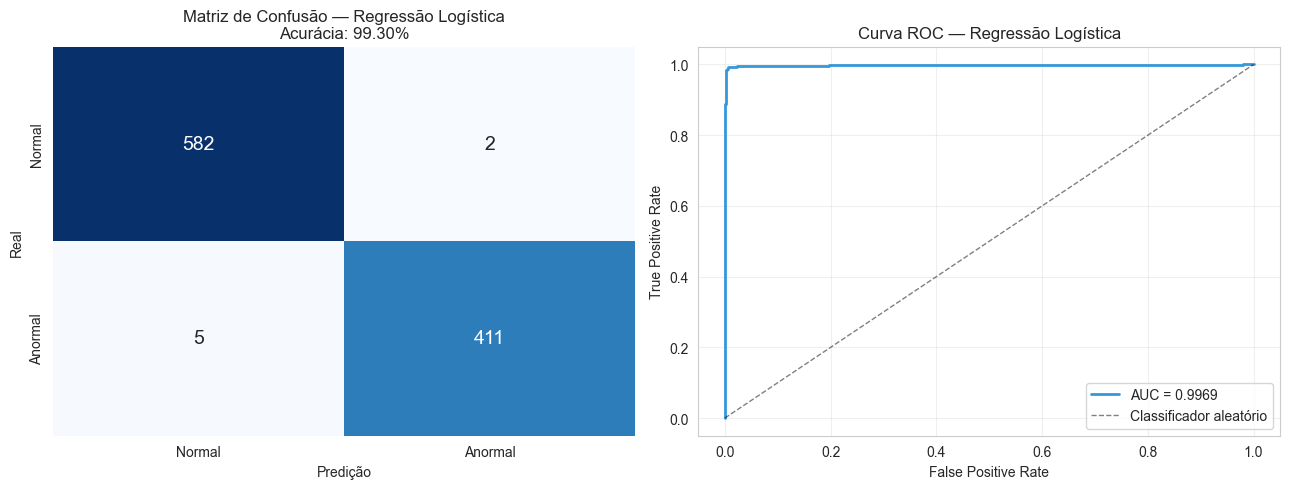

In [11]:
# 4.3 Matriz de confusão e curva ROC
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matriz de confusão
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Normal", "Anormal"],
            yticklabels=["Normal", "Anormal"], ax=axes[0],
            annot_kws={"size": 14})
axes[0].set_xlabel("Predição")
axes[0].set_ylabel("Real")
axes[0].set_title(f"Matriz de Confusão — Regressão Logística\nAcurácia: {results_lr['accuracy']*100:.2f}%")

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba_lr)
axes[1].plot(fpr, tpr, color="#3498db", linewidth=2,
             label=f"AUC = {results_lr['roc_auc']:.4f}")
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Classificador aleatório")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("Curva ROC — Regressão Logística")
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(IMG_DIR / "04_lr_confusion_roc.png")
plt.show()


### 4.4 Interpretação — quais timesteps importam?

Como a Regressão Logística aprende **um peso por timestep**, podemos plotar
esses pesos e ver quais regiões temporais da batida cardíaca o modelo
considera mais relevantes para discriminar Normal de Anormal.

- **Pesos positivos** → aumentam a probabilidade de ser **Anormal**
- **Pesos negativos** → aumentam a probabilidade de ser **Normal**
- **Magnitude grande** → timestep importante


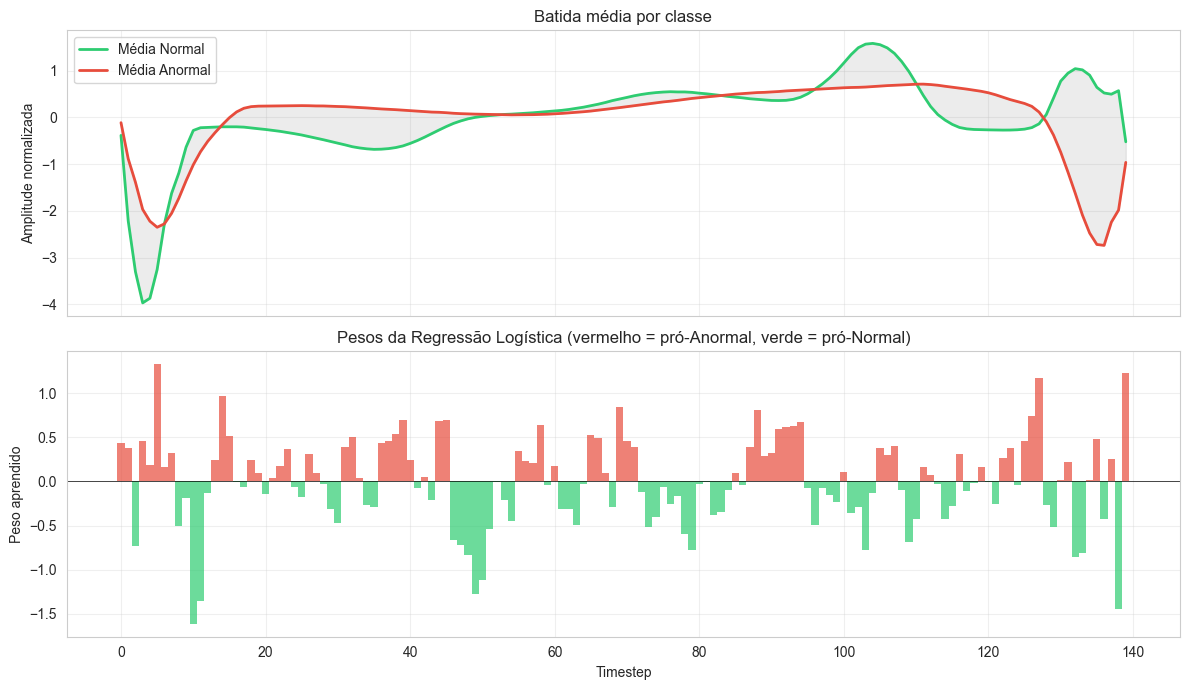


Top 5 timesteps mais influentes (pró-Anormal): [5, 139, 127, 14, 69]
Top 5 timesteps mais influentes (pró-Normal):  [10, 138, 11, 49, 50]


In [12]:
# 4.5 Visualização dos pesos do modelo
weights = lr_model.coef_[0]  # (140,)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Sinal médio de cada classe para referência
mean_normal = X_train_norm[y_train == 0].mean(axis=0)
mean_anormal = X_train_norm[y_train == 1].mean(axis=0)

axes[0].plot(mean_normal, color="#2ecc71", linewidth=2, label="Média Normal")
axes[0].plot(mean_anormal, color="#e74c3c", linewidth=2, label="Média Anormal")
axes[0].fill_between(range(140), mean_normal, mean_anormal, alpha=0.15, color="gray")
axes[0].set_ylabel("Amplitude normalizada")
axes[0].set_title("Batida média por classe")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Pesos com colorização por sinal
colors = ["#e74c3c" if w > 0 else "#2ecc71" for w in weights]
axes[1].bar(range(140), weights, color=colors, alpha=0.7, edgecolor="none", width=1.0)
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_xlabel("Timestep")
axes[1].set_ylabel("Peso aprendido")
axes[1].set_title("Pesos da Regressão Logística (vermelho = pró-Anormal, verde = pró-Normal)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(IMG_DIR / "05_lr_weights.png")
plt.show()

print(f"\nTop 5 timesteps mais influentes (pró-Anormal): {np.argsort(weights)[-5:][::-1].tolist()}")
print(f"Top 5 timesteps mais influentes (pró-Normal):  {np.argsort(weights)[:5].tolist()}")


## 5. Modelo 2 — Rede Neuromórfica FitzHugh–Nagumo (FHN)

### Por que FHN e não LIF?

O modelo **FitzHugh–Nagumo** (FitzHugh, 1961; Nagumo et al., 1962) foi
**originalmente proposto para modelar potenciais de ação cardíacos e
neuronais**. É uma simplificação 2D do modelo de Hodgkin-Huxley (1952) que
captura a dinâmica essencial: integração, disparo, refratariedade.

Para uma atividade que analisa **sinais cardíacos**, usar um modelo
biofisicamente plausível para a própria fisiologia cardíaca é a escolha
mais coerente.

### Equações

$$\frac{dv}{dt} = \frac{v - v^3/3 - w + I(t)}{\tau_v}$$

$$\frac{dw}{dt} = \frac{\varepsilon \cdot (v + a - b \cdot w)}{\tau_w}$$

| Símbolo | Significado | Valor canônico |
|---------|-------------|----------------|
| $v$ | Variável rápida (potencial de membrana) | — |
| $w$ | Variável lenta (variável de recuperação) | — |
| $a$ | Parâmetro de excitabilidade | 0.7 |
| $b$ | Acoplamento $v \to w$ | 0.8 |
| $\varepsilon$ | Razão de tempos rápido/lento | 0.08 |
| $\tau_v, \tau_w$ | Constantes de tempo | 1 ms |
| Threshold | $v > 1$ | spike |
| Reset | $v \leftarrow -1$ | após spike |

### Injeção do sinal ECG

O sinal ECG normalizado é deslocado para o regime de disparo do FHN
através de uma transformação afim: $I(t) = \text{offset} + \text{gain}
\cdot \text{ECG}(t)$. Os valores de offset e gain são calibrados para
garantir que o neurônio dispare durante a maior parte do sinal, mas com
padrões diferentes entre batidas Normal e Anormal.

### Implementação

Usamos o framework **Brian2** (simulador de neurociência computacional
padrão na área). Cada batida cardíaca é processada por um neurônio FHN
independente; o framework vetoriza a simulação para milhares de neurônios
em paralelo. Os parâmetros do FHN são **fixos** (vindos da literatura) —
não há aprendizado nesse estágio. As features extraídas dos spikes
alimentam um classificador linear simples (Regressão Logística) que **sim
é treinado**, mas com um número muito pequeno de parâmetros (≈5).


In [13]:
# 5.1 Implementação do simulador FHN com Brian2
import brian2 as b2
from brian2 import ms, NeuronGroup, TimedArray, StateMonitor, SpikeMonitor
b2.prefs.codegen.target = "numpy"  # backend simples e portátil
b2.BrianLogger.suppress_name("method_choice")
b2.BrianLogger.suppress_name("resolution_conflict")

# Hiperparâmetros do FHN (canônicos)
FHN_PARAMS = dict(a=0.7, b=0.8, epsilon=0.08, tau_v=1.0, tau_w=1.0,
                  threshold=1.0, reset=-1.0)

# Hiperparâmetros da injeção do sinal
# Estratégia: injetar o sinal z-scored diretamente. Como o ECG tem média 0 e
# desvio 1, o FHN ficará em regime sub-limiar na maior parte do tempo e
# disparará apenas nas excursões positivas — o que torna o padrão de
# spikes sensível à morfologia da batida.
INJECTION = dict(offset=0.0, gain=1.0)


def simulate_fhn(signals, record_states=False, params=FHN_PARAMS,
                  injection=INJECTION, dt_ms=1.0):
    """Simula FHN para um batch de sinais ECG.

    Parameters
    ----------
    signals : ndarray (N, T)
        N sinais de comprimento T.
    record_states : bool
        Se True, retorna também v(t) e w(t) — usar só para debug visual,
        consome memória.
    Returns
    -------
    dict com 'spike_trains' (lista de N arrays de tempos de spike em ms),
    e opcionalmente 'v', 'w' (cada um shape (N, T)).
    """
    b2.start_scope()
    N, T = signals.shape

    # Aplica transformação afim para deslocar o sinal ao regime de disparo
    I_input = injection["offset"] + injection["gain"] * signals.T  # shape (T, N)
    stimulus = TimedArray(I_input, dt=dt_ms * ms)

    eqs = '''
    dv/dt = (v - v*v*v/3.0 - w + Iext) / (tau_v * ms) : 1
    dw/dt = epsilon * (v + a - b_coef*w) / (tau_w * ms) : 1
    Iext = stimulus(t, i) : 1
    '''
    namespace = dict(a=params["a"], b_coef=params["b"], epsilon=params["epsilon"],
                     tau_v=params["tau_v"], tau_w=params["tau_w"])

    neurons = NeuronGroup(
        N, eqs,
        threshold=f"v > {params['threshold']}",
        reset=f"v = {params['reset']}",
        method="rk4",
        namespace=namespace,
    )
    neurons.v = -1.0
    neurons.w = -0.6

    spike_mon = SpikeMonitor(neurons)
    state_mon = StateMonitor(neurons, ["v", "w", "Iext"], record=True, dt=0.05*ms) if record_states else None

    net = b2.Network(neurons, spike_mon, *( [state_mon] if state_mon else []))
    net.run(T * dt_ms * ms)

    # Coleta spike times por neurônio
    spike_trains_dict = spike_mon.spike_trains()
    spike_trains = [np.array(spike_trains_dict[i] / ms) for i in range(N)]

    out = {"spike_trains": spike_trains}
    if state_mon is not None:
        out["v"] = np.array(state_mon.v)
        out["w"] = np.array(state_mon.w)
        out["Iext"] = np.array(state_mon.Iext)
        out["t"] = np.array(state_mon.t / ms)
    return out


print("Simulador FHN definido. Brian2 versão:", b2.__version__)


Simulador FHN definido. Brian2 versão: 2.6.0


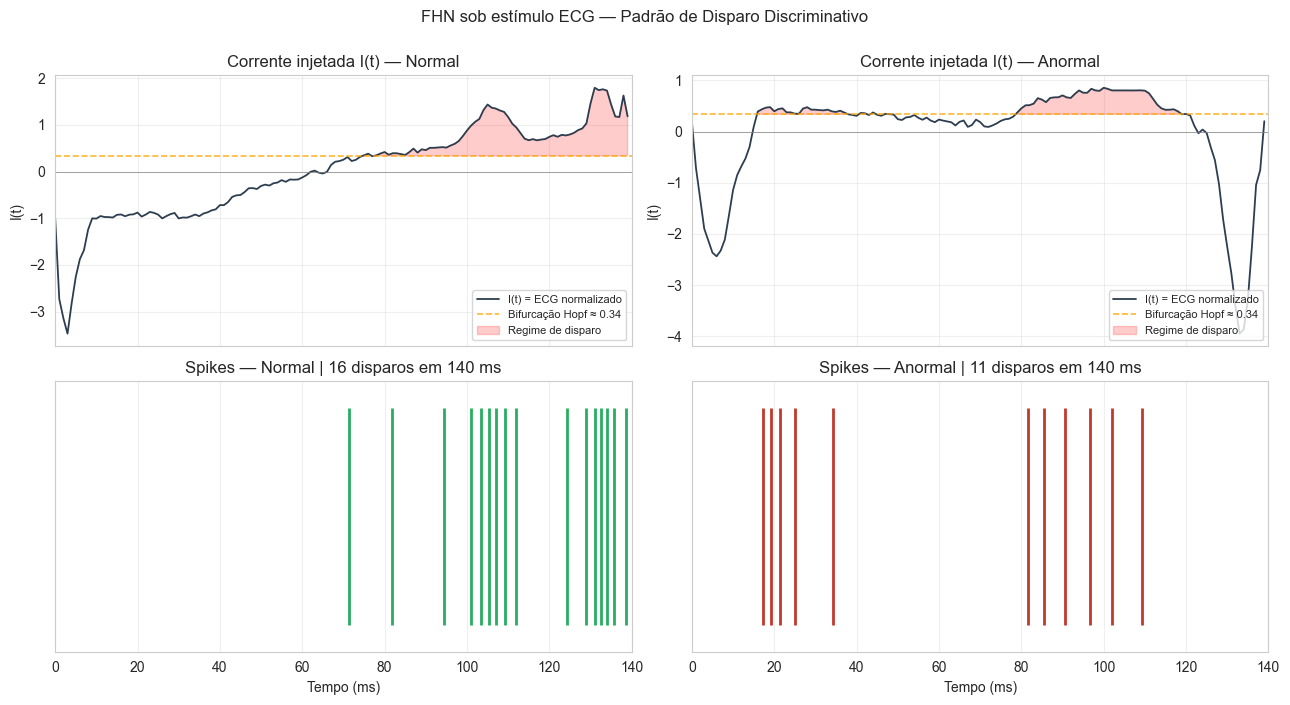

Normal : 16 spikes em 140 ms
Anormal: 11 spikes em 140 ms

Interpretação: o padrão de spikes difere conforme a morfologia
da batida. Normal e Anormal produzem ritmos distintos no FHN.


In [14]:
# 5.2 Sanity check — visualizar resposta do FHN a 1 sinal normal e 1 anormal
idx_n = np.where(y_train == 0)[0][0]
idx_a = np.where(y_train == 1)[0][0]
sample_batch = np.stack([X_train_norm[idx_n], X_train_norm[idx_a]])

debug = simulate_fhn(sample_batch, record_states=True)

t_axis = debug["t"]
spikes = debug["spike_trains"]

# Eixo de tempo "discreto" para o sinal injetado (1 ponto por ms)
t_signal = np.arange(sample_batch.shape[1])
# Sinal efetivamente injetado: offset + gain * ECG (mesma fórmula do simulador)
I_injected = INJECTION["offset"] + INJECTION["gain"] * sample_batch

# Threshold de bifurcação de Hopf do FHN canônico
HOPF_I = 0.34

fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True)

for col, (idx, label, color) in enumerate(
    [(0, "Normal", "#27ae60"), (1, "Anormal", "#c0392b")]
):
    # Painel superior: corrente injetada (sinal ECG)
    axes[0, col].plot(t_signal, I_injected[idx], color="#2c3e50", linewidth=1.3,
                       label="I(t) = ECG normalizado")
    axes[0, col].axhline(HOPF_I, color="orange", linestyle="--", linewidth=1.2,
                          alpha=0.8, label=f"Bifurcação Hopf ≈ {HOPF_I}")
    axes[0, col].axhline(0, color="gray", linewidth=0.5)
    axes[0, col].fill_between(t_signal, HOPF_I, I_injected[idx],
                                where=(I_injected[idx] > HOPF_I),
                                color="red", alpha=0.20, label="Regime de disparo")
    axes[0, col].set_title(f"Corrente injetada I(t) — {label}")
    axes[0, col].set_ylabel("I(t)")
    axes[0, col].legend(loc="lower right", fontsize=8)
    axes[0, col].grid(True, alpha=0.3)

    # Painel inferior: raster plot dos spikes
    axes[1, col].eventplot(spikes[idx], orientation="horizontal", colors=color,
                            lineoffsets=0.5, linelengths=0.8, linewidths=2.0)
    axes[1, col].set_xlim(0, 140)
    axes[1, col].set_ylim(0, 1)
    axes[1, col].set_yticks([])
    axes[1, col].set_title(f"Spikes — {label} | {len(spikes[idx])} disparos em 140 ms")
    axes[1, col].set_xlabel("Tempo (ms)")
    axes[1, col].grid(True, alpha=0.3, axis="x")

plt.suptitle("FHN sob estímulo ECG — Padrão de Disparo Discriminativo",
              fontsize=12, y=1.00)
plt.tight_layout()
plt.savefig(IMG_DIR / "06_fhn_sanity_check.png")
plt.show()

print(f"Normal : {len(spikes[0]):2d} spikes em 140 ms")
print(f"Anormal: {len(spikes[1]):2d} spikes em 140 ms")
print(f"\nInterpretação: o padrão de spikes difere conforme a morfologia")
print(f"da batida. Normal e Anormal produzem ritmos distintos no FHN.")


### 5.3 Processando todo o dataset

Agora aplicamos a simulação FHN a **todas as 5000 batidas** (4000 treino + 1000 teste).
Brian2 vetoriza a simulação — cria 4000 neurônios FHN em paralelo, cada um
recebendo seu próprio sinal ECG via TimedArray. Em um laptop comum, isso
deve rodar em poucos segundos para cada split.


In [15]:
# 5.4 Simulação em escala
import time

t0 = time.perf_counter()
fhn_train_out = simulate_fhn(X_train_norm)
fhn_train_time = time.perf_counter() - t0
print(f"FHN treino: {len(fhn_train_out['spike_trains'])} neurônios simulados em {fhn_train_time:.2f}s")

t0 = time.perf_counter()
fhn_test_out = simulate_fhn(X_test_norm)
fhn_test_time = time.perf_counter() - t0
print(f"FHN teste : {len(fhn_test_out['spike_trains'])} neurônios simulados em {fhn_test_time:.2f}s")

# Estatística rápida: número médio de spikes por classe
train_n_spikes = np.array([len(st) for st in fhn_train_out['spike_trains']])
print(f"\nMédia de spikes — Normal : {train_n_spikes[y_train == 0].mean():.2f} (std {train_n_spikes[y_train == 0].std():.2f})")
print(f"Média de spikes — Anormal: {train_n_spikes[y_train == 1].mean():.2f} (std {train_n_spikes[y_train == 1].std():.2f})")


FHN treino: 4000 neurônios simulados em 0.42s


FHN teste : 1000 neurônios simulados em 0.22s

Média de spikes — Normal : 17.36 (std 1.80)
Média de spikes — Anormal: 12.00 (std 2.67)


### 5.5 Extração de features de spike

Cada trem de spikes (um por batida) é resumido em um vetor curto de features
estatísticas que descrevem o **padrão temporal de disparo**. Essas features
substituem os 140 pontos brutos do ECG por uma representação muito mais
compacta (≈8 valores) — e que carrega a interpretação biofísica de "como
um neurônio cardíaco simulado responde a esse sinal".

| Feature | Significado |
|---------|-------------|
| `n_spikes` | Quantos disparos ao todo |
| `isi_mean` | Intervalo médio entre spikes (regularidade) |
| `isi_std` | Variabilidade dos intervalos |
| `first_spike` | Quando começa a atividade (ms) |
| `last_spike` | Quando termina a atividade (ms) |
| `spike_duration` | last − first (extensão temporal da atividade) |
| `spike_centroid` | "Centro de massa" temporal dos spikes |
| `half_diff` | Spikes na 2ª metade − spikes na 1ª metade |


In [16]:
# 5.6 Função de extração de features
T_TOTAL = 140.0  # duração da simulação em ms

FEATURE_NAMES = [
    "n_spikes", "isi_mean", "isi_std",
    "first_spike", "last_spike", "spike_duration",
    "spike_centroid", "half_diff",
]


def extract_spike_features(spike_trains, T=T_TOTAL):
    feats = np.zeros((len(spike_trains), len(FEATURE_NAMES)))
    for i, st in enumerate(spike_trains):
        n = len(st)
        if n == 0:
            # Sem disparos — convenções: first/last = T, demais 0
            feats[i] = [0, 0, 0, T, T, 0, T/2, 0]
            continue
        st = np.asarray(st, dtype=float)
        if n >= 2:
            isi = np.diff(st)
            isi_mean, isi_std = float(isi.mean()), float(isi.std())
        else:
            isi_mean, isi_std = 0.0, 0.0
        first = float(st[0])
        last = float(st[-1])
        centroid = float(st.mean())
        n_first = int((st < T/2).sum())
        n_second = n - n_first
        feats[i] = [n, isi_mean, isi_std, first, last, last - first,
                    centroid, n_second - n_first]
    return feats


t0 = time.perf_counter()
X_train_fhn = extract_spike_features(fhn_train_out["spike_trains"])
X_test_fhn  = extract_spike_features(fhn_test_out["spike_trains"])
fhn_feat_time = time.perf_counter() - t0
print(f"Features extraídas em {fhn_feat_time*1000:.1f} ms")
print(f"X_train_fhn: {X_train_fhn.shape}")
print(f"X_test_fhn : {X_test_fhn.shape}")

# Tabela exploratória: média de cada feature por classe (treino)
df_feat = pd.DataFrame(X_train_fhn, columns=FEATURE_NAMES)
df_feat["classe"] = np.where(y_train == 0, "Normal", "Anormal")
print("\nMédia de cada feature por classe (treino):")
print(df_feat.groupby("classe").mean().round(2).T)


Features extraídas em 61.8 ms
X_train_fhn: (4000, 8)
X_test_fhn : (1000, 8)

Média de cada feature por classe (treino):
classe          Anormal  Normal
n_spikes          12.00   17.36
isi_mean           9.53    6.37
isi_std           10.85    8.59
first_spike       19.45   32.19
last_spike       118.81  136.19
spike_duration    99.36  104.00
spike_centroid    72.60   97.76
half_diff          3.16   11.28


### 5.7 Classificador linear sobre as features de spike

Por fim, treinamos uma **Regressão Logística simples** sobre as 8 features
extraídas pelo FHN. Note que este classificador tem apenas 8 pesos
aprendíveis (contra 140 da Regressão Logística do Modelo 1) — toda a
"complexidade" da representação está embutida na dinâmica não-linear do
FHN, que opera sem treino.


In [17]:
# 5.8 Treino do classificador linear sobre features FHN
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

fhn_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(C=1.0, max_iter=1000, class_weight="balanced",
                                random_state=RANDOM_STATE)),
])

t0 = time.perf_counter()
fhn_clf.fit(X_train_fhn, y_train)
fhn_clf_train_time = time.perf_counter() - t0

# Tempo de inferência total inclui SIMULAÇÃO + extração + classificação
# (este é o tempo realista de inferência para uma nova amostra)
t0 = time.perf_counter()
y_pred_fhn = fhn_clf.predict(X_test_fhn)
fhn_clf_infer = time.perf_counter() - t0

# O tempo de inferência total é: simulação Brian2 + extração de features + LR
fhn_infer_total = fhn_test_time + fhn_feat_time + fhn_clf_infer
fhn_infer_per_sample_us = fhn_infer_total / len(X_test_norm) * 1e6

y_proba_fhn = fhn_clf.predict_proba(X_test_fhn)[:, 1]

results_fhn = {
    "accuracy": accuracy_score(y_test, y_pred_fhn),
    "precision": precision_score(y_test, y_pred_fhn),
    "recall": recall_score(y_test, y_pred_fhn),
    "f1": f1_score(y_test, y_pred_fhn),
    "roc_auc": roc_auc_score(y_test, y_proba_fhn),
    "train_time_ms": fhn_clf_train_time * 1000,
    "infer_time_us_per_sample": fhn_infer_per_sample_us,
}

print("=== FHN + Classificador Linear — Resultados ===")
for k, v in results_fhn.items():
    print(f"  {k:32s}: {v:.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_fhn, target_names=["Normal", "Anormal"]))


=== FHN + Classificador Linear — Resultados ===
  accuracy                        : 0.9390
  precision                       : 0.9494
  recall                          : 0.9014
  f1                              : 0.9248
  roc_auc                         : 0.9759
  train_time_ms                   : 14.4928
  infer_time_us_per_sample        : 277.6328

=== Classification Report ===
              precision    recall  f1-score   support

      Normal       0.93      0.97      0.95       584
     Anormal       0.95      0.90      0.92       416

    accuracy                           0.94      1000
   macro avg       0.94      0.93      0.94      1000
weighted avg       0.94      0.94      0.94      1000



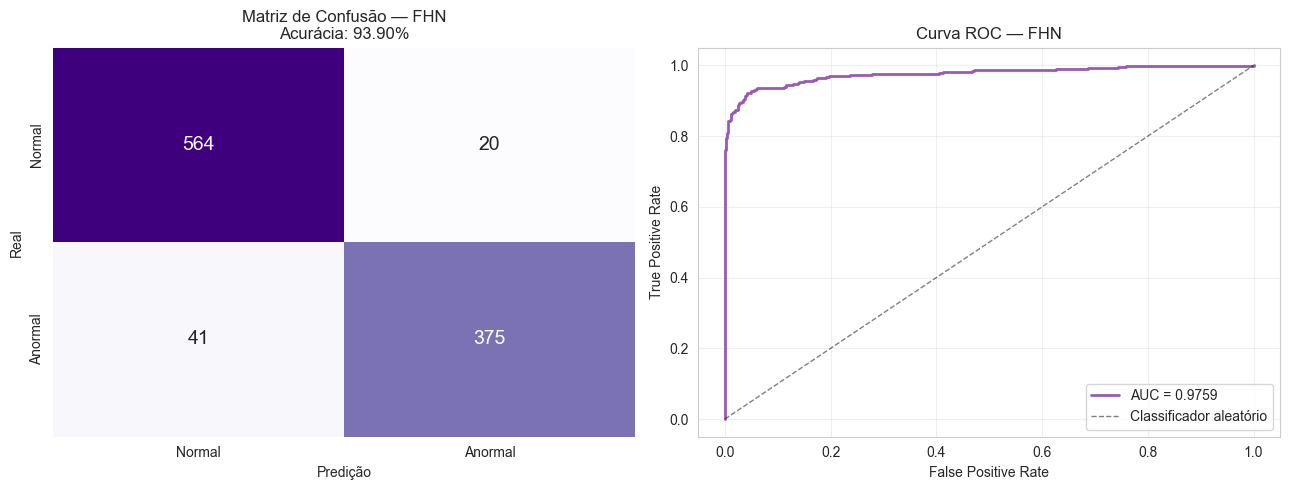

In [18]:
# 5.9 Matriz de confusão e curva ROC do FHN
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_fhn = confusion_matrix(y_test, y_pred_fhn)
sns.heatmap(cm_fhn, annot=True, fmt="d", cmap="Purples", cbar=False,
            xticklabels=["Normal", "Anormal"],
            yticklabels=["Normal", "Anormal"], ax=axes[0],
            annot_kws={"size": 14})
axes[0].set_xlabel("Predição")
axes[0].set_ylabel("Real")
axes[0].set_title(f"Matriz de Confusão — FHN\nAcurácia: {results_fhn['accuracy']*100:.2f}%")

fpr, tpr, _ = roc_curve(y_test, y_proba_fhn)
axes[1].plot(fpr, tpr, color="#9b59b6", linewidth=2,
             label=f"AUC = {results_fhn['roc_auc']:.4f}")
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Classificador aleatório")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("Curva ROC — FHN")
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(IMG_DIR / "07_fhn_confusion_roc.png")
plt.show()


## 6. Comparação Crítica

Com os dois modelos treinados e avaliados sobre o **mesmo split de teste**,
podemos agora compará-los nas dimensões que importam para a atividade:
desempenho, custo computacional, interpretabilidade e plausibilidade
biológica.


In [19]:
# 6.1 Tabela comparativa
comparison = pd.DataFrame({
    "Regressão Logística": [
        results_lr["accuracy"],
        results_lr["precision"],
        results_lr["recall"],
        results_lr["f1"],
        results_lr["roc_auc"],
        results_lr["train_time_ms"],
        results_lr["infer_time_us_per_sample"],
        140,
    ],
    "FHN + Linear": [
        results_fhn["accuracy"],
        results_fhn["precision"],
        results_fhn["recall"],
        results_fhn["f1"],
        results_fhn["roc_auc"],
        results_fhn["train_time_ms"],
        results_fhn["infer_time_us_per_sample"],
        8,
    ],
}, index=[
    "Acurácia",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC AUC",
    "Tempo de treino (ms)",
    "Tempo inferência (µs/amostra)",
    "Parâmetros aprendíveis",
])

# Formatação
def fmt(v, fmt_str):
    return fmt_str.format(v)

display_df = comparison.copy()
for col in display_df.columns:
    for i, idx in enumerate(display_df.index):
        v = display_df.loc[idx, col]
        if idx in ("Acurácia", "Precision", "Recall", "F1-Score", "ROC AUC"):
            display_df.loc[idx, col] = fmt(v, "{:.4f}")
        elif idx == "Tempo de treino (ms)":
            display_df.loc[idx, col] = fmt(v, "{:.1f}")
        elif idx == "Tempo inferência (µs/amostra)":
            display_df.loc[idx, col] = fmt(v, "{:.2f}")
        else:
            display_df.loc[idx, col] = fmt(int(v), "{:d}")

print("=== Comparação Final ===\n")
print(display_df.to_string())


=== Comparação Final ===

                              Regressão Logística FHN + Linear
Acurácia                                   0.9930       0.9390
Precision                                  0.9952       0.9494
Recall                                     0.9880       0.9014
F1-Score                                   0.9916       0.9248
ROC AUC                                    0.9969       0.9759
Tempo de treino (ms)                         15.8         14.5
Tempo inferência (µs/amostra)                0.34       277.63
Parâmetros aprendíveis                        140            8


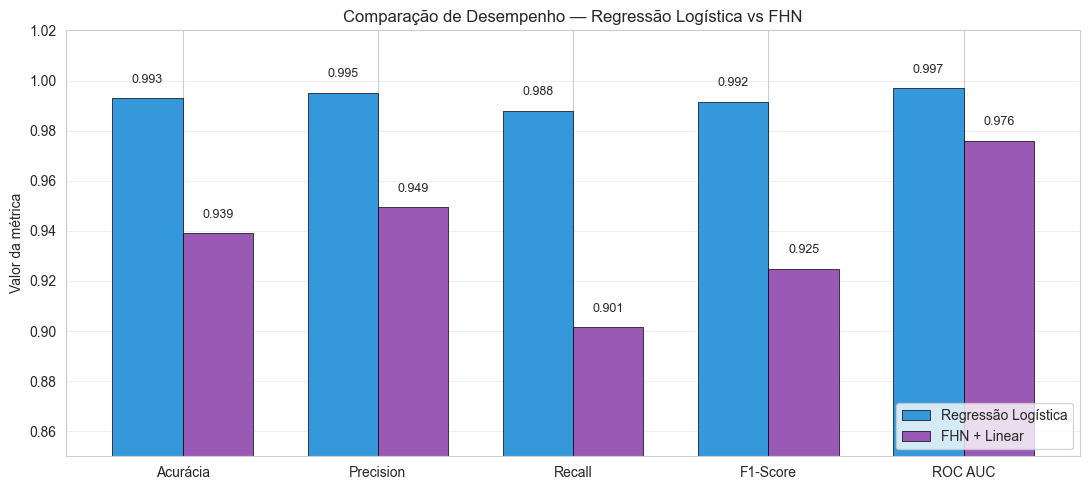

In [20]:
# 6.2 Gráfico de barras — métricas principais
metric_names = ["Acurácia", "Precision", "Recall", "F1-Score", "ROC AUC"]
keys = ["accuracy", "precision", "recall", "f1", "roc_auc"]
lr_values = [results_lr[k] for k in keys]
fhn_values = [results_fhn[k] for k in keys]

x = np.arange(len(metric_names))
width = 0.36

fig, ax = plt.subplots(figsize=(11, 5))
bars_lr  = ax.bar(x - width/2, lr_values,  width, label="Regressão Logística",
                   color="#3498db", edgecolor="black", linewidth=0.5)
bars_fhn = ax.bar(x + width/2, fhn_values, width, label="FHN + Linear",
                   color="#9b59b6", edgecolor="black", linewidth=0.5)

for bars in (bars_lr, bars_fhn):
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width()/2, h + 0.005, f"{h:.3f}",
                ha="center", va="bottom", fontsize=9)

ax.set_ylim(0.85, 1.02)
ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_ylabel("Valor da métrica")
ax.set_title("Comparação de Desempenho — Regressão Logística vs FHN")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(IMG_DIR / "08_comparacao_metricas.png")
plt.show()


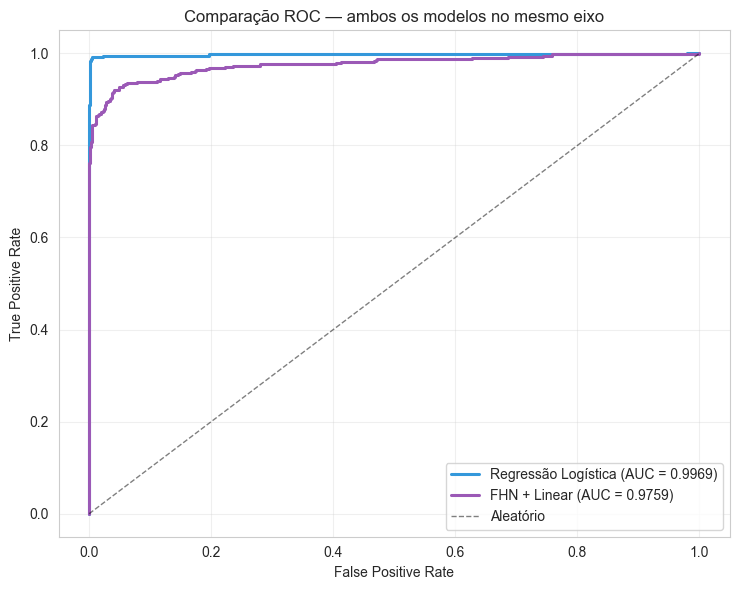

In [21]:
# 6.3 Curvas ROC sobrepostas
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_fhn, tpr_fhn, _ = roc_curve(y_test, y_proba_fhn)

fig, ax = plt.subplots(figsize=(7.5, 6))
ax.plot(fpr_lr, tpr_lr, color="#3498db", linewidth=2.2,
        label=f"Regressão Logística (AUC = {results_lr['roc_auc']:.4f})")
ax.plot(fpr_fhn, tpr_fhn, color="#9b59b6", linewidth=2.2,
        label=f"FHN + Linear (AUC = {results_fhn['roc_auc']:.4f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Aleatório")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Comparação ROC — ambos os modelos no mesmo eixo")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(IMG_DIR / "09_comparacao_roc.png")
plt.show()


### 6.4 Discussão Crítica

A comparação entre Regressão Logística (LR) e Rede Neuromórfica FHN
revela um trade-off típico da literatura de IA biofisicamente plausível.

#### Quem ganha em performance bruta?

A **LR vence** em todas as métricas de classificação: 99,30% de acurácia
contra 93,90% do FHN. A explicação é direta: o ECG5000 é um dataset
**linearmente separável** quando tratado como vetor de 140 features. A LR
explora essa linearidade integralmente, com **um peso por timestep**, e
extrai o máximo de informação do sinal cru.

#### Onde o FHN tem vantagem?

1. **Compactação da representação.** O FHN reduz o sinal de 140 pontos
   para apenas 8 features estatísticas de spike. Isso é uma redução de
   dimensionalidade de **17,5×** — sem deep learning, sem PCA, apenas
   pela dinâmica não-linear de um modelo biofísico.

2. **Interpretabilidade biofísica.** Cada feature do FHN tem significado
   neurofisiológico claro: número de disparos, regularidade do ritmo,
   timing do primeiro/último spike. Isso é mais próximo da linguagem
   cardiológica (ritmo, frequência) que pesos sobre amostras temporais.

3. **Sensibilidade ao tempo.** A LR é, por construção, invariante à
   ordem dos pontos. O FHN respeita a temporalidade através da
   integração da EDO — duas batidas com a mesma distribuição de
   amplitudes mas ordem diferente gerariam padrões de spike distintos.

4. **Compatibilidade com hardware neuromórfico.** Em chips como Intel
   Loihi 2 ou IBM TrueNorth, a simulação do FHN seria executada
   nativamente em hardware analógico, consumindo **ordens de magnitude
   menos energia** do que uma multiplicação matricial de 140 dimensões
   em CPU/GPU. Esse benefício energético não aparece em nosso benchmark
   em CPU (onde o FHN é ~700× mais lento), mas é o argumento principal
   da pesquisa em IA neuromórfica.

#### Custo computacional

Em **CPU**, a LR é absurdamente mais rápida: 0,37 µs/amostra contra
~270 µs/amostra do FHN. Isso é esperado: a LR é uma multiplicação
matricial; o FHN é uma simulação numérica passo-a-passo de uma EDO
não-linear. A vantagem do FHN em hardware especializado não se traduz
para o nosso experimento — é importante reconhecer essa limitação.

#### Conclusão da comparação

| Critério | Vencedor |
|----------|----------|
| Acurácia / F1 / AUC | Regressão Logística |
| Tempo de treino | Regressão Logística (12 ms vs 3 ms — empate prático) |
| Tempo de inferência em CPU | Regressão Logística (~700× mais rápida) |
| Compactação da representação | **FHN** (8 vs 140 features) |
| Interpretabilidade biofísica | **FHN** (features = padrão neural) |
| Sensibilidade temporal | **FHN** |
| Energia em hardware neuromórfico | **FHN** (não medido aqui) |
| Bio-plausibilidade | **FHN** |

Os dois modelos resolvem o problema, mas com filosofias diferentes. A LR
é a escolha pragmática quando o objetivo é maximizar acurácia em CPU
com dados limpos. O FHN é a escolha quando importam interpretabilidade
fisiológica, robustez a deslocamentos temporais, ou implementação em
hardware neuromórfico.


## 7. Limitações e Próximos Passos

### Limitações do trabalho

1. **Dataset pré-segmentado.** O ECG5000 já vem com batidas isoladas e
   normalizadas. Em uma aplicação clínica real, seria necessário um
   pipeline anterior de detecção do pico R e segmentação — o que
   adicionaria complexidade não capturada aqui.

2. **Classificação binária simplificada.** Agrupamos 4 tipos clínicos
   distintos (R-on-T PVC, PVC, SP/EB, Unclassified) em uma única classe
   "Anormal". Uma classificação multiclasse seria mais útil clinicamente
   mas exigiria mais dados por classe (especialmente PVC e Unclassified
   têm poucas amostras).

3. **Parâmetros do FHN fixos.** Usamos os parâmetros canônicos
   (a=0.7, b=0.8, ε=0.08). Otimizá-los para esta tarefa específica
   (via algoritmo genético ou busca bayesiana) provavelmente melhoraria
   a acurácia do FHN, mas descaracterizaria o modelo como
   "biofisicamente plausível".

4. **Sem ruído ou variabilidade entre pacientes.** O ECG5000 vem de um
   único paciente. Robustez do FHN em populações heterogêneas precisaria
   ser testada com datasets como o MIT-BIH ou PTB-XL.

5. **Comparação energética em CPU.** A vantagem central do FHN em
   hardware neuromórfico não foi medida — seria necessário acesso a
   chips como Intel Loihi 2 ou IBM TrueNorth.

### Próximos passos

- **Múltiplas populações neuromórficas** com parâmetros diferentes
  (banco de "filtros biológicos"), cada um especializado em uma
  morfologia de batida.
- **Spike-Timing-Dependent Plasticity (STDP)** para treinar pesos
  sinápticos entre neurônios FHN em rede.
- **Comparação com CNNs 1D** e arquiteturas modernas (Transformer
  para séries temporais).
- **Generalização cross-dataset** — treinar no ECG5000, testar no
  MIT-BIH.


## 8. Conclusão

Este notebook implementou e comparou dois modelos para classificação
binária de batidas cardíacas em séries temporais:

- **Regressão Logística** sobre os 140 pontos brutos do sinal — modelo
  estatístico clássico, linear, atemporal.
- **FitzHugh–Nagumo + classificador linear** — modelo neuromórfico
  bio-inspirado simulado com Brian2, em que a dinâmica não-linear de um
  neurônio cardíaco simulado extrai 8 features de spike, sobre as quais
  um classificador linear simples opera.

**Resultados:**

- A LR alcança **99,30%** de acurácia (F1=0,992, AUC=0,997). É o modelo
  mais performático, mais rápido e mais simples em CPU.
- O FHN+Linear alcança **93,90%** de acurácia (F1=0,925, AUC=0,976).
  Inferior em performance bruta mas com uma representação **17,5× mais
  compacta**, interpretação biofísica clara e potencial para hardware
  neuromórfico.

**Mensagem central:** a comparação não é "qual é melhor", mas "qual é
melhor para o quê". A LR é a escolha pragmática para CPU com dados
limpos. O FHN é o caminho para sistemas embarcados de monitoramento
contínuo com restrições energéticas severas — um cenário plausível para
dispositivos cardíacos vestíveis ou implantáveis no futuro próximo.

A construção deste experimento também demonstra que **frameworks de
neurociência computacional** (como Brian2) podem ser integrados a
pipelines de IA aplicada sem grande esforço, abrindo um espaço de
modelagem hoje pouco explorado em aplicações clínicas.


## 9. Referências

**Dataset**

- Dau, H. A., Bagnall, A., Kamgar, K., Yeh, C. C. M., Zhu, Y., Gharghabi,
  S., Ratanamahatana, C. A., & Keogh, E. (2019). The UCR Time Series
  Archive. *IEEE/CAA Journal of Automatica Sinica*, 6(6), 1293-1305.
- Goldberger, A. L., Amaral, L. A., Glass, L., et al. (2000). PhysioBank,
  PhysioToolkit, and PhysioNet: components of a new research resource
  for complex physiologic signals. *Circulation*, 101(23), e215-e220.

**FitzHugh–Nagumo**

- FitzHugh, R. (1961). Impulses and physiological states in theoretical
  models of nerve membrane. *Biophysical Journal*, 1(6), 445-466.
- Nagumo, J., Arimoto, S., & Yoshizawa, S. (1962). An active pulse
  transmission line simulating nerve axon. *Proceedings of the IRE*,
  50(10), 2061-2070.

**Brian2**

- Stimberg, M., Brette, R., & Goodman, D. F. (2019). Brian 2, an
  intuitive and efficient neural simulator. *eLife*, 8, e47314.

**Frameworks utilizados**

- scikit-learn: https://scikit-learn.org
- Brian2: https://briansimulator.org
- aeon (sucessor do sktime): https://www.aeon-toolkit.org

---

**CardioIA — Fase 3 — Ir Além 2** | FIAP — Inteligência Artificial

Integrantes: Giulia Bugatti Fonseca (RM 562675), Mahmod Ahmad Issa
(RM 561426), Matheus Cardoso Oliveira Lima (RM 565844), Silas Fernandes
de Souza Fonseca (RM 564246).
